# Solomon's Desk — Workspace

This notebook lets you define Lefschetz fibrations, compute their orbit graphs, and export stabilizer generators to GAP.

Run the cells **top to bottom**. Each section is independent once the setup cell (Cell 1) has been run.

In [1]:
# Cell 1 — Setup (run this first every session)
%matplotlib inline
from ethan import Fibration

---
## Example 1 — Alternating genus-1 fibration

The simplest example: a Lefschetz fibration over the disk with fiber a once-punctured torus,
whose monodromy alternates between the two standard Dehn twists $T_a$ and $T_b$.

In [2]:
# Genus-1 fiber (once-punctured torus), 4 twists alternating a_0, b_0
fib = Fibration(genus=1, punctures=1)
fib.add_twist('a_0')
fib.add_twist('b_0')
fib.add_twist('a_0')
fib.add_twist('b_0')

print(fib)

Fibration(genus=1, punctures=1, twists=4)


In [3]:
# Build the orbit graph with the representation reduced mod 5.
# mod=N makes the orbit finite and computable.
fib.build_orbit()
print(f"Orbit has {fib.orbit_size()} nodes")

Orbit has 27 nodes


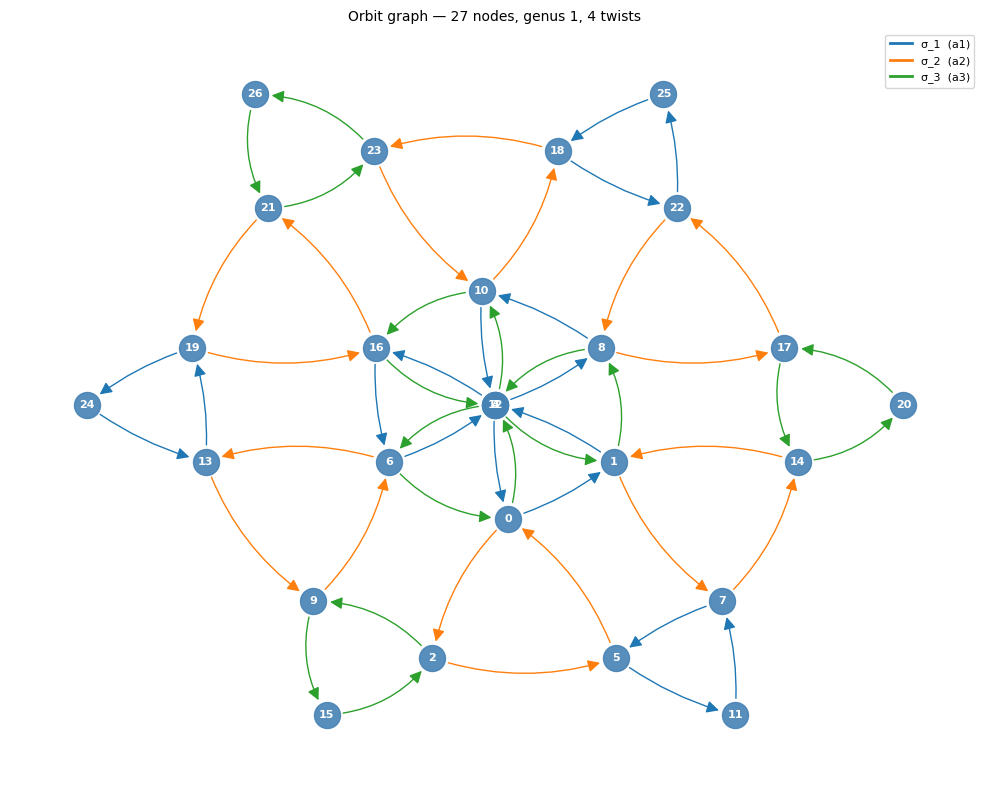

In [4]:
# View the orbit graph inline
fib.show_orbit(layout='spectral')

In [5]:
# Save the orbit graph as a PNG image
fib.save_orbit_png('orbit_example1.png')

Orbit graph saved to: orbit_example1.png


In [14]:
# Export stabilizer generators to GAP.
# The output is a script defining a free group F and subgroup H.
fib.gap_generators_file('stab_example1.g')

# You can also print the script directly:
print(fib.gap_generators())

GAP stabilizer generators written to: stab_example1.g
# Stabilizer of the monodromy representation in B_4
# Fibration: genus 1, 4 twists
# Orbit: full (curver)  (27 nodes)
#
# s[i] denotes the i-th standard Artin generator sigma_i
LoadPackage("ACE");
TCENUM := ACETCENUM;;
LoadPackage("FR");
F := SurfaceBraidFpGroup(4,0,1);
s := GeneratorsOfGroup(F);
stab_gens := [
  s[2]*s[1]*s[2]^(-1),
  s[3]*s[1]*s[3]^(-1)*s[1]^(-1),
  s[3]*s[2]*s[3]^(-1),
  s[1]*s[1]*s[1],
  s[1]*s[1]*s[2]*s[1]^(-1)*s[1]^(-1),
  s[2]*s[2]*s[2],
  s[2]*s[2]*s[3]*s[2]^(-1)*s[2]^(-1),
  s[3]*s[3]*s[3],
  s[3]*s[3]*s[1]*s[3]^(-1)*s[3]^(-1)*s[1]^(-1),
  s[1]*s[2]*s[1]*s[2]^(-1)*s[2]^(-1),
  s[1]*s[2]*s[3]*s[2]^(-1)*s[1]^(-1),
  s[1]*s[3]*s[1]*s[3]^(-1)*s[1]^(-1)*s[1]^(-1),
  s[2]*s[3]*s[2]*s[3]^(-1)*s[3]^(-1),
  s[2]*s[3]*s[1]*s[3]^(-1)*s[2]^(-1),
  s[1]*s[1]*s[3]*s[1]*s[3]^(-1),
  s[2]*s[2]*s[1]*s[1]*s[2]^(-1)*s[1]^(-1),
  s[2]*s[2]*s[1]*s[2]*s[1]^(-1)*s[2]^(-1)*s[2]^(-1),
  s[2]*s[2]*s[1]*s[3]*s[1]^(-1)*s[2]^(-1)*s[2]^

---
## Example 2 — Looping over several primes

The orbit size depends on the prime. This loop computes the orbit for each prime
and saves both a picture and a GAP file.

In [ ]:
fib2 = Fibration(genus=1, punctures=1)
fib2.add_twist('a_0')
fib2.add_twist('b_0')
fib2.add_twist('a_0')
fib2.add_twist('b_0')
fib2.add_twist('a_0')

for p in [2, 3, 5, 7]:
    fib2.build_orbit(mod=p)
    size = fib2.orbit_size()
    print(f"mod {p}: {size} nodes")
    fib2.save_orbit_png(f'orbit_mod{p}.png')
    fib2.gap_generators_file(f'stab_mod{p}.g')

---
## Example 3 — Custom mapping classes

You can define your own mapping classes by composing standard Dehn twists.
Access the underlying curver surface via `fib.surface`, then use `*` to compose
and `** -1` for the inverse.

In [ ]:
fib3 = Fibration(genus=1, punctures=1)
S = fib3.surface   # the underlying curver surface object

# Define a custom mapping class: conjugate T_a by T_b
conj = S('b_0') * S('a_0') * S('b_0') ** -1
fib3.define_curve('conj_a', conj)

fib3.add_twist('a_0')
fib3.add_twist('conj_a')   # use the custom curve by name
fib3.add_twist('b_0')

fib3.build_orbit(mod=3)
print(f"Orbit has {fib3.orbit_size()} nodes")
fib3.show_orbit()

---
## Example 4 — Higher genus fiber

To work with a genus-2 fiber surface, load with `genus=2`.
The available curve names are `a_0, b_0, c_0, a_1, b_1` (and `c_0` connecting the two handles).

In [12]:
fib4 = Fibration(genus=3, punctures=1)
# Basic chain: b_0, c_0, b_1  (chain of Dehn twists across the genus-2 surface)
fib4.add_twist('a_0')
fib4.add_twist('b_0')
fib4.add_twist('c_0')
fib4.add_twist('b_1')
fib4.add_twist('c_1')

fib4.build_orbit()
print(f"Orbit has {fib4.orbit_size()} nodes")


Orbit has 1296 nodes


---
## Example 5 — Sage BraidGroup Integration

Once the orbit is built, the stabilizer generators can be lifted into Sage's
native `BraidGroup` type, giving access to invariants like Burau matrices,
Lawrence–Krammer representations, and subgroup membership tests directly
in Sage.  These methods require the **SageMath 10.8 + Solomon** kernel.

In [ ]:
fib_sage = Fibration(genus=1, punctures=1)
for c in ['a_0', 'b_0', 'a_0', 'b_0']:
    fib_sage.add_twist(c)
fib_sage.build_orbit()

B = fib_sage.sage_braid_group()
print("Braid group:", B)
print("Generators:", B.gens())

In [ ]:
stab = fib_sage.sage_stabilizer()
print(f"{len(stab)} Schreier generators")
for b in stab[:5]:
    print(" ", b, "  Tietze:", b.Tietze())

In [ ]:
H = fib_sage.sage_stabilizer_subgroup()
print("Stabilizer subgroup:", H)

In [ ]:
print("Burau matrices of the first 3 stabilizer generators:")
for b in stab[:3]:
    print(b, "->")
    print(b.burau_matrix())
    print()

## ---
## Scratch space

Use the cells below for your own experiments.

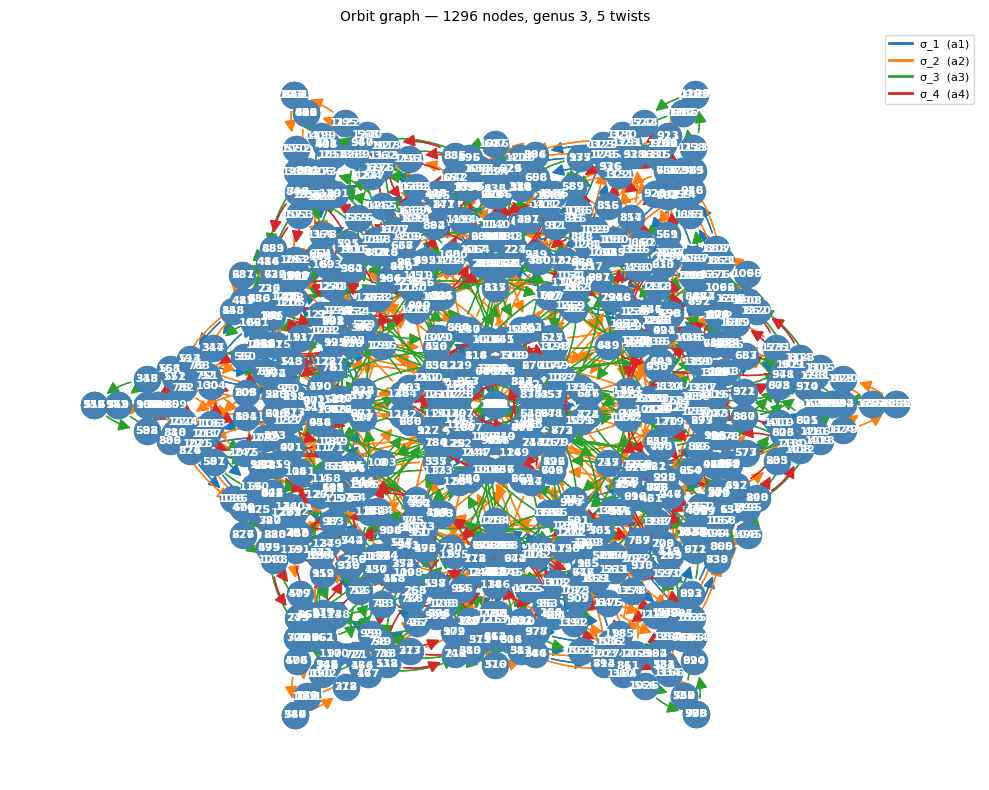

In [13]:
fib4.show_orbit(layout='spectral')

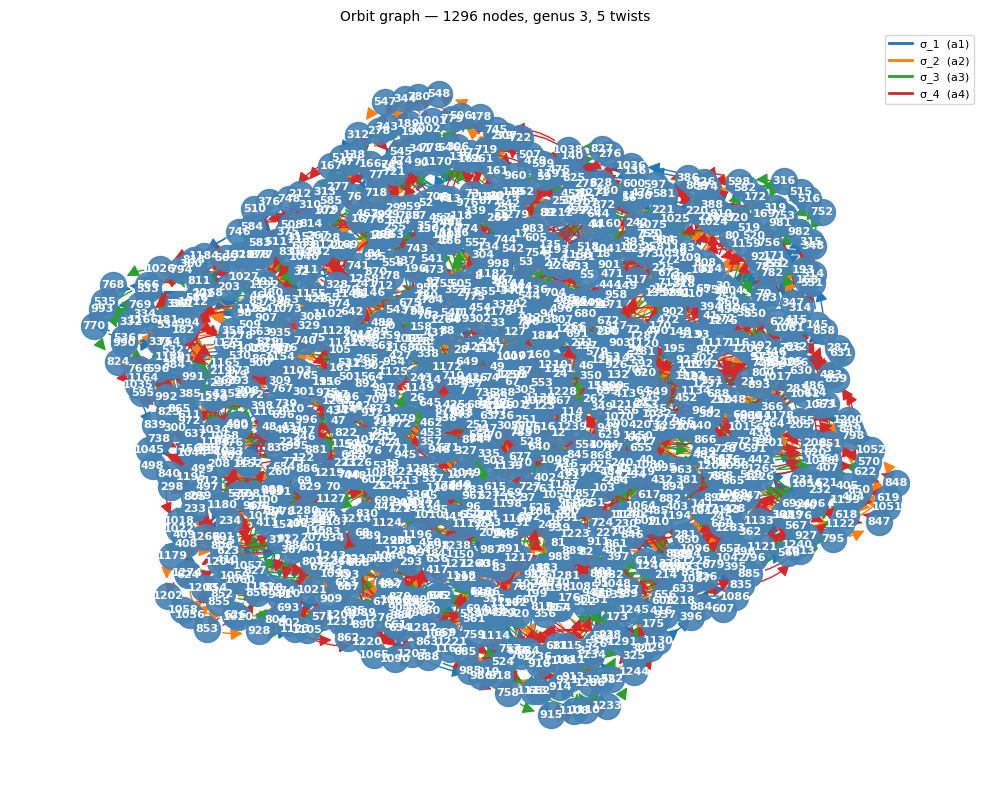

In [14]:
fib4.show_orbit(layout='kamada_kawai')

In [30]:
fib = Fibration(genus=3, punctures=1)
# Basic chain: b_0, c_0, b_1  (chain of Dehn twists across the genus-2 surface)
fib.add_twist('a_0')
fib.add_twist('b_0')
fib.add_twist('c_0')
fib.add_twist('b_1')
fib.add_twist('c_1')
fib.add_twist('b_2')

fib.build_orbit()
print(f"Orbit has {fib.orbit_size()} nodes")


KeyboardInterrupt: 

In [ ]:
fib4.show_orbit(layout='spectral')